<a href="https://colab.research.google.com/github/shadowalvan/OPT810S_Group_Assignment/blob/main/OPT_Group_Assignment_Question_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4: Stochastic Gradient Descent

## Group Information

**Group:** A  
**Random Seed:** 10

Seed 10 will be used in all stochastic gradient descent experiments to ensure that the results are reproducible.

In [2]:
%pip install -q --no-deps d2l==1.0.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 3.2 MB/s eta 0:00:00


### Exercise 4.1

Experiment with different learning-rate schedules for stochastic gradient descent and with different numbers of iterations. In particular, plot the distance from the optimal solution $(0,0)$ as a function of the number of iterations.

**[10 Marks]**

### Explanation of Exercise 4.1

**The Goal:**
The core idea of this exercise is to find the minimum point of a function. Imagine you're blindfolded on a hilly landscape and you want to find the lowest point in a valley. You can only feel the slope directly under your feet. Stochastic Gradient Descent (SGD) is like taking small steps downhill based on that local slope.

In this specific problem, the function we're trying to minimize is $f(x_1, x_2) = x_1^2 + 2x_2^2$. The absolute lowest point (the **optimal solution**) for this function is at $(0, 0)$.

**Stochastic Gradient Descent (SGD):**
*   **Gradient:** This is the direction of the steepest uphill slope. To go downhill, you move in the opposite direction of the gradient.
*   **Stochastic:** In a real-world scenario, getting the *exact* slope of the entire landscape can be very slow. So, instead, we often estimate the slope based on a small, random sample of the data. This estimate isn't perfect; it has some 'noise' or randomness, which is why it's called 'stochastic'. In this exercise, noise is explicitly added to the gradient to simulate this.
*   **Learning Rate (`eta`):** This controls how big of a step you take in the downhill direction. A large learning rate means bigger steps, which might get you there faster but could also make you overshoot the minimum. A small learning rate means tiny steps, which are safer but might take a very long time to reach the minimum.

**Learning Rate Schedules:**
The problem asks to experiment with different **learning rate schedules**. This means instead of using a fixed step size (`eta`) throughout the entire journey, we change it over time. The code explores three ways to do this:
1.  **Constant Learning Rate:** The step size remains the same throughout. (Like always taking a 1-meter step).
2.  **Exponential Learning Rate:** The step size gets smaller over time, specifically decreasing exponentially. (Like taking a 1-meter step, then 0.98-meter, then 0.98*0.98-meter, and so on).
3.  **Inverse Square Root Learning Rate:** The step size also decreases over time, but at a rate proportional to the inverse of the square root of the number of steps taken. (It gets smaller, but perhaps not as quickly as exponential initially, then slower).

**Iterations and Distance from Optimal Solution:**
*   **Iterations:** Each step you take is one iteration. The more iterations, the more chances you have to get closer to the minimum.
*   **Distance from (0,0):** After each step (or iteration), we measure how far our current position $(x_1, x_2)$ is from the optimal solution $(0,0)$. We want this distance to become as small as possible.

**What the Code Does:**
The provided code `Fwwy-dhb8Pas` sets up and runs this experiment. It:
1.  Defines the `f(x1, x2)` function and its `f_grad` (the slope).
2.  Implements the `sgd` function, which takes a step based on the noisy gradient and a specific learning rate schedule.
3.  Defines the three `lr_schedules` (constant, exponential, inverse square root).
4.  Runs SGD for different numbers of `steps` (50, 100, 200) for each learning rate schedule.
5.  For each run, it records the `distances` from the optimal solution at every iteration.
6.  Finally, it generates two types of plots:
    *   **Distance Plots:** These show how the distance from the optimal solution changes over the number of iterations for each learning rate schedule. You'd expect the distance to generally decrease.
    *   **Contour Plot with Trajectories:** This shows the 'path' taken by SGD on the landscape of the function for each learning rate schedule, specifically for 200 iterations. This helps visualize how directly or erratically each method approaches the minimum.


This exercise helps us understand that choosing the right learning rate and how it changes over time (`learning rate schedule`) is crucial for how effectively and efficiently SGD finds the minimum of a function. Some schedules might converge faster, while others might be more stable and avoid overshooting.

epoch 50, x1: -0.137953, x2: 0.086476
epoch 50, x1: -0.043230, x2: 0.053364
epoch 50, x1: -0.347580, x2: 0.028353


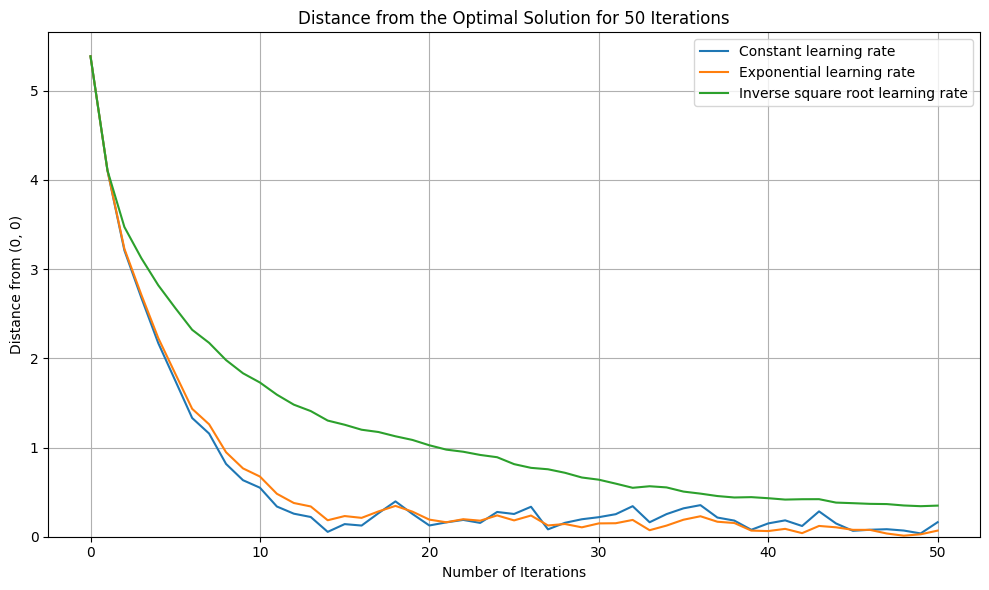

epoch 100, x1: 0.109694, x2: -0.010816
epoch 100, x1: 0.130587, x2: -0.023666
epoch 100, x1: -0.014069, x2: -0.018391


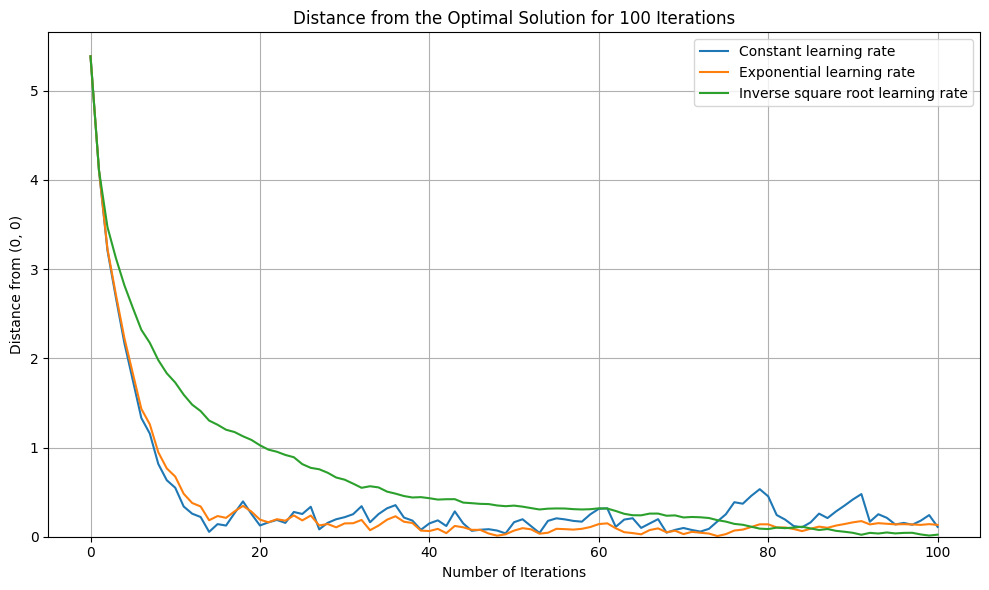

epoch 200, x1: 0.319263, x2: 0.135825
epoch 200, x1: 0.060465, x2: -0.000005
epoch 200, x1: 0.045269, x2: 0.017160


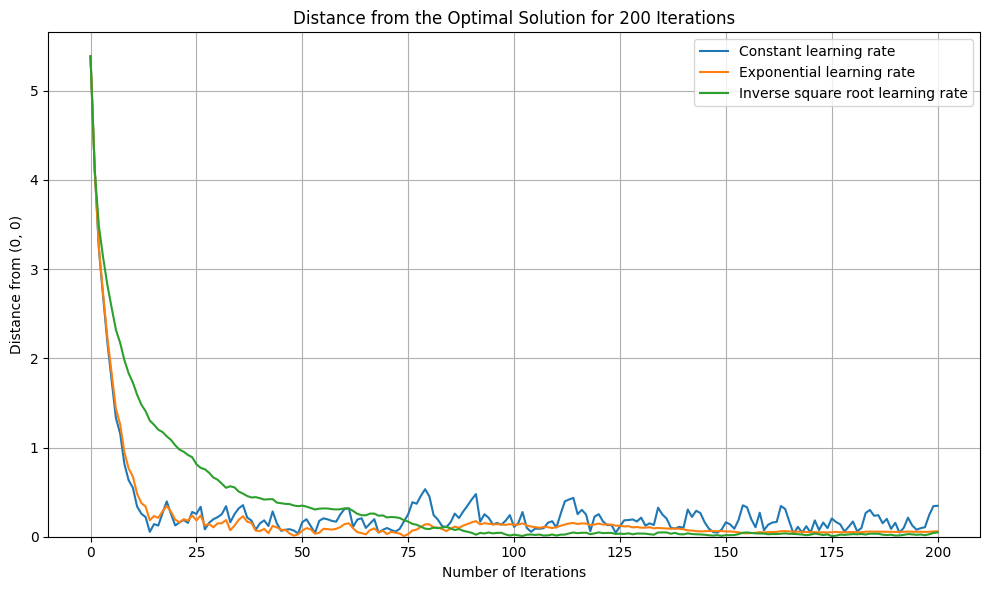

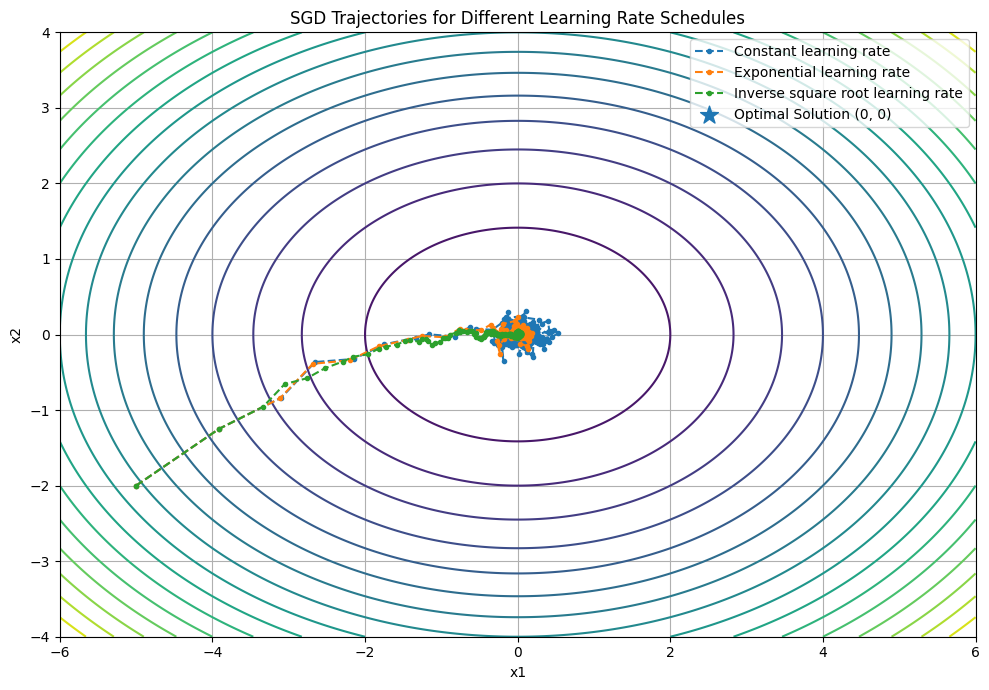

SGD Results
------------------------------------------------------------------------------------------
Iterations     Learning Rate                           Final Distance    Minimum Distance  
------------------------------------------------------------------------------------------
50             Constant learning rate                  0.162816          0.036956          
50             Exponential learning rate               0.068677          0.011626          
50             Inverse square root learning rate       0.348735          0.342279          
100            Constant learning rate                  0.110226          0.036956          
100            Exponential learning rate               0.132714          0.007390          
100            Inverse square root learning rate       0.023155          0.013194          
200            Constant learning rate                  0.346954          0.032648          
200            Exponential learning rate               0.060465       

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from d2l import tensorflow as d2l

# Our group's seed
tf.random.set_seed(10)


def f(x1, x2):  # Objective function
    return x1 ** 2 + 2 * x2 ** 2


def f_grad(x1, x2):  # Gradient of the objective function
    return 2 * x1, 4 * x2


# Base learning rate
eta = 0.1

# Current learning rate schedule
lr = None

# Current iteration number
t = 0


def sgd(x1, x2, s1, s2, f_grad):
    global t

    # Calculate the gradient
    g1, g2 = f_grad(x1, x2)

    # Simulate noisy gradient using scalar noise
    g1 += tf.random.normal([], 0.0, 1)
    g2 += tf.random.normal([], 0.0, 1)

    # Calculate the learning rate for the current iteration
    eta_t = eta * lr()

    # Move to the next iteration
    t += 1

    # Update x1 and x2
    return (x1 - eta_t * g1, x2 - eta_t * g2, 0, 0)


def constant_lr():
    # Keep the learning rate constant
    return 1


def exponential_lr():
    # Decrease the learning rate exponentially
    return 0.98 ** t


def inverse_sqrt_lr():
    # Decrease the learning rate using the inverse square root
    return 1 / math.sqrt(t + 1)


def run_sgd(lr_schedule, steps):
    global lr
    global t

    # Reset the seed so each schedule uses the same noise
    tf.random.set_seed(10)

    # Set the learning rate schedule
    lr = lr_schedule

    # Reset the iteration number
    t = 0

    # Run stochastic gradient descent
    trace = d2l.train_2d(
        sgd,
        steps=steps,
        f_grad=f_grad
    )

    distances = []

    # Calculate the distance from each point to the optimum (0, 0)
    for x1, x2 in trace:
        distance = math.sqrt(
            float(x1) ** 2 + float(x2) ** 2
        )

        distances.append(distance)

    return trace, distances


# Learning rate schedules to compare
lr_schedules = {
    "Constant learning rate": constant_lr,
    "Exponential learning rate": exponential_lr,
    "Inverse square root learning rate": inverse_sqrt_lr
}

# Different numbers of iterations
steps_list = [50, 100, 200]

# Store the final results
results = []

# Store the traces for the contour graph
final_traces = {}


# Run the experiment for each number of iterations
for steps in steps_list:
    plt.figure(figsize=(10, 6))

    # Run the experiment for each learning rate schedule
    for lr_name, lr_schedule in lr_schedules.items():
        trace, distances = run_sgd(
            lr_schedule,
            steps
        )

        # Store the final distance
        results.append(
            {
                "steps": steps,
                "lr_name": lr_name,
                "final_distance": distances[-1],
                "minimum_distance": min(distances)
            }
        )

        # Store the 200-iteration trace for the contour graph
        if steps == 200:
            final_traces[lr_name] = trace

        # Plot distance against iteration number
        plt.plot(
            range(len(distances)),
            distances,
            label=lr_name
        )

    # Label and display the distance graph
    plt.xlabel("Number of Iterations")
    plt.ylabel("Distance from (0, 0)")
    plt.title(
        f"Distance from the Optimal Solution for {steps} Iterations"
    )
    plt.ylim(bottom=0)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Create values for the contour graph
x1_values = np.linspace(-6, 6, 400)
x2_values = np.linspace(-4, 4, 400)

X1, X2 = np.meshgrid(
    x1_values,
    x2_values
)

Z = f(X1, X2)


# Create a contour-line graph
plt.figure(figsize=(10, 7))

plt.contour(
    X1,
    X2,
    Z,
    levels=20
)

# Plot the trajectory for each learning rate schedule
for lr_name, trace in final_traces.items():
    x1_history = [
        float(point[0])
        for point in trace
    ]

    x2_history = [
        float(point[1])
        for point in trace
    ]

    plt.plot(
        x1_history,
        x2_history,
        marker="o",
        markersize=3,
        linestyle="--",
        label=lr_name
    )

# Mark the optimal solution
plt.scatter(
    0,
    0,
    marker="*",
    s=180,
    label="Optimal Solution (0, 0)"
)

# Label and display the contour graph
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(
    "SGD Trajectories for Different Learning Rate Schedules"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Display the final distance for each experiment
print("SGD Results")
print("-" * 90)

print(
    f"{'Iterations':<15}"
    f"{'Learning Rate':<40}"
    f"{'Final Distance':<18}"
    f"{'Minimum Distance':<18}"
)

print("-" * 90)

for result in results:
    print(
        f"{result['steps']:<15}"
        f"{result['lr_name']:<40}"
        f"{result['final_distance']:<18.6f}"
        f"{result['minimum_distance']:<18.6f}"
    )

### Exercise 4.2

Prove that for the function $f(x_1,x_2)=x_1^2+2x_2^2$, adding normal noise to the gradient is equivalent to minimizing the loss function $f(\mathbf{x},\mathbf{w})=(x_1-w_1)^2+2(x_2-w_2)^2$, where $\mathbf{x}$ is drawn from a normal distribution.

**[5 Marks]**

In [ ]:
def random_f(x1, x2, w1, w2):  # Random loss function
    return (x1 - w1) ** 2 + 2 * (x2 - w2) ** 2


def random_f_grad(x1, x2, w1, w2):  # Gradient of the random loss
    return 2 * (x1 - w1), 4 * (x2 - w2)


# Reset the seed
tf.random.set_seed(10)

# Select a point for comparing the gradients
x1 = tf.constant(1.5, dtype=tf.float32)
x2 = tf.constant(-0.8, dtype=tf.float32)

# Calculate the original gradient
g1, g2 = f_grad(x1, x2)

# Generate normal noise
noise1 = tf.random.normal([], 0.0, 1)
noise2 = tf.random.normal([], 0.0, 1)

# Add normal noise to the original gradient
noisy_g1 = g1 + noise1
noisy_g2 = g2 + noise2

# Choose w1 and w2 so the gradients are equal
w1 = -noise1 / 2
w2 = -noise2 / 4

# Calculate the gradient of the random loss
random_g1, random_g2 = random_f_grad(
    x1,
    x2,
    w1,
    w2
)

# Display the gradient results
print("Original gradient with normal noise:")
print(f"g1 = {float(noisy_g1):.6f}")
print(f"g2 = {float(noisy_g2):.6f}")

print("\nGradient of the random loss function:")
print(f"g1 = {float(random_g1):.6f}")
print(f"g2 = {float(random_g2):.6f}")

# Check that the gradients are equal
tf.debugging.assert_near(noisy_g1, random_g1)
tf.debugging.assert_near(noisy_g2, random_g2)

print("\nThe two gradients are equal.")


# Number of random samples
number_of_samples = 100000

# Generate normally distributed values of w1 and w2
w1_samples = tf.random.normal(
    [number_of_samples],
    mean=0.0,
    stddev=0.5
)

w2_samples = tf.random.normal(
    [number_of_samples],
    mean=0.0,
    stddev=0.25
)

# Calculate the random loss for all samples
random_loss_values = random_f(
    x1,
    x2,
    w1_samples,
    w2_samples
)

# Estimate the expected random loss
expected_random_loss = tf.reduce_mean(
    random_loss_values
)

# Calculate the original objective function value
original_loss = f(x1, x2)

# The theoretical expected loss is f(x1, x2) + 3/8
theoretical_loss = original_loss + 3 / 8

# Display the loss results
print("\nOriginal objective function value:")
print(f"{float(original_loss):.6f}")

print("\nEstimated expected random loss:")
print(f"{float(expected_random_loss):.6f}")

print("\nTheoretical expected random loss:")
print(f"{float(theoretical_loss):.6f}")


Original gradient with normal noise:
g1 = 2.124219
g2 = -2.716821

Gradient of the random loss function:
g1 = 2.124219
g2 = -2.716821

The two gradients are equal.

Original objective function value:
3.530000

Estimated expected random loss:
3.901000

Theoretical expected random loss:
3.905000


### Exercise 4.3

Compare the convergence of stochastic gradient descent when sampling from $\{(x_1,y_1),(x_2,y_2),\ldots,(x_n,y_n)\}$ with replacement and when sampling without replacement.

**[5 Marks]**

### Explanation of Exercise 4.3

**The Goal:**
In this exercise, you're asked to compare two common ways of drawing data samples when using Stochastic Gradient Descent (SGD) to train a simple linear model. These two methods are:
1.  **Sampling with Replacement:** Imagine you have a bag of data points. When you pick one to update your model, you note its value, and then you put it back into the bag. This means the same data point can be picked multiple times, even within a single "round" (epoch) of training.
2.  **Sampling without Replacement:** With this method, once you pick a data point from the bag, you *don't* put it back. You keep picking unique data points until the bag is empty. Once the bag is empty, that marks the end of one "round" (epoch), and you then refill the bag (or reset the list of available samples) and start again.

The exercise aims to show how these two sampling strategies affect how quickly and smoothly the model converges to a good solution.

**Stochastic Gradient Descent (SGD) Context:**
Recall that SGD updates a model's parameters (like the `w` and `b` in a linear regression) by looking at the gradient (slope) calculated from a *single* data point (or a small batch of data points) at a time. The choice of *which* data point to use for each update is what sampling with/without replacement addresses.

**1. Sampling with Replacement (`sgd_with_replacement`):**
*   **How it works:** In each step, a data point is randomly selected from the entire dataset. It's possible for the same data point to be picked again in the very next step, or many times within an epoch.
*   **Analogy:** Rolling a die. Each roll is independent, and you can get the same number repeatedly.
*   **Characteristics:** This method introduces more randomness or "noise" into the updates. It can sometimes lead to more volatile updates but might explore the parameter space more broadly. It's simple to implement.

**2. Sampling without Replacement (`sgd_without_replacement`):**
*   **How it works:** Before starting a new "epoch" (a full pass over the dataset), the entire dataset is typically shuffled. Then, data points are drawn one by one in that shuffled order, ensuring that each data point is used exactly once per epoch.
*   **Analogy:** Shuffling a deck of cards and dealing them out one by one. You won't see the same card twice until you've gone through the whole deck.
*   **Characteristics:** This method provides a more consistent exposure to all data points within an epoch, leading to potentially more stable convergence, especially as the optimization progresses. It's very common in practice (often called "shuffling the dataset before each epoch").

**What the Code (`QIgPyFU5-CpJ`) Does:**
The provided code demonstrates this comparison using a simple linear regression problem ($y = wx + b$):
1.  **Generates Data:** It creates a synthetic dataset (`x_data`, `y_data`) where `y` is linearly related to `x` with some added noise.
2.  **`calculate_loss` Function:** Defines the Mean Squared Error (MSE) loss function, which measures how well the model's predictions match the actual `y_data`.
3.  **`sgd_with_replacement` Function:**
    *   Initializes `w` and `b` (weight and bias).
    *   For each epoch, it runs `number_of_samples` steps.
    *   In each step, `tf.random.uniform` is used to pick a random `index`, meaning data points are selected *with replacement*.
    *   It calculates the gradient and updates `w` and `b`.
    *   It records the loss after each epoch.
4.  **`sgd_without_replacement` Function:**
    *   Also initializes `w` and `b`.
    *   For each epoch, it *shuffles* the `indices` of the dataset using `tf.random.shuffle`.
    *   It then iterates through these shuffled indices, ensuring each data point is used exactly once per epoch (sampling *without replacement*).
    *   It calculates the gradient and updates `w` and `b`.
    *   It records the loss after each epoch.
5.  **Runs and Plots:** Both SGD functions are run for a set number of `epochs`. The code then plots the `loss_history` for both methods on the same graph, allowing for a visual comparison of their convergence paths. Finally, it prints the final Mean Squared Error, `w`, and `b` values for each method.

**Why This Matters:**
Understanding the difference between these sampling strategies is crucial for practical machine learning. While both can work, sampling without replacement (by shuffling the dataset at the beginning of each epoch) is generally preferred in practice because it provides a more robust and stable path to convergence by ensuring all data points contribute equally to the gradient updates over an epoch, preventing some points from being over-represented and others from being ignored for extended periods.

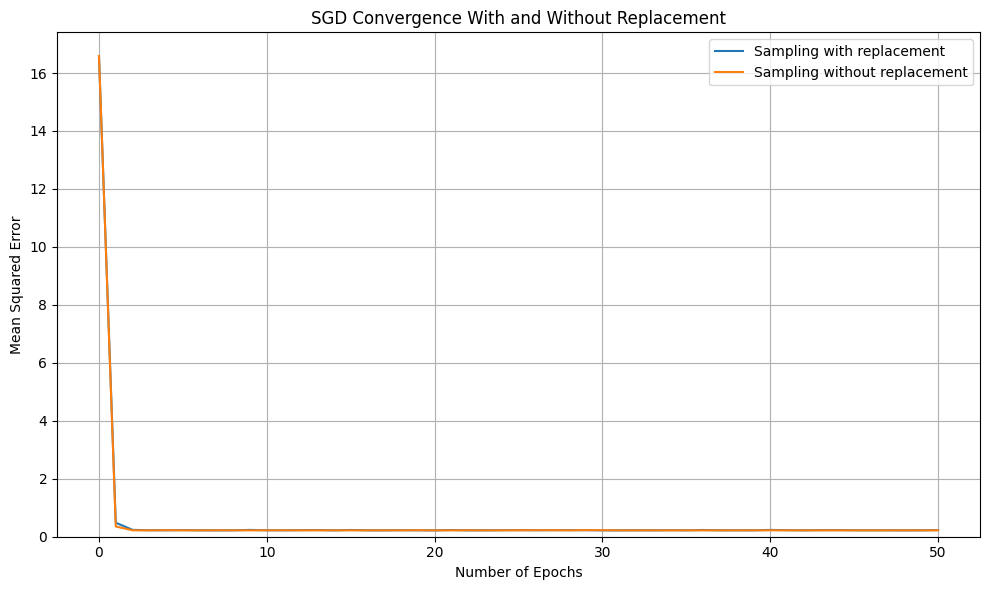

SGD Sampling Results
--------------------------------------------------------------------------------
Sampling Method                    Final MSE      w              b              
--------------------------------------------------------------------------------
With replacement                   0.228986       3.056559       2.093224       
Without replacement                0.220780       3.018214       1.977154       


In [ ]:
# Reset the seed
tf.random.set_seed(10)

# Create a sample dataset
number_of_samples = 100

x_data = tf.linspace(
    -2.0,
    2.0,
    number_of_samples
)

y_data = (
    3 * x_data
    + 2
    + tf.random.normal(
        [number_of_samples],
        0.0,
        0.5
    )
)


def calculate_loss(w, b):
    # Calculate predictions for the complete dataset
    predictions = w * x_data + b

    # Calculate the mean squared error
    return tf.reduce_mean(
        (predictions - y_data) ** 2
    )


def sgd_with_replacement(epochs, learning_rate):
    # Reset the seed
    tf.random.set_seed(10)

    # Initial model parameters
    w = tf.Variable(0.0)
    b = tf.Variable(0.0)

    # Store the loss after each epoch
    loss_history = [
        float(calculate_loss(w, b))
    ]

    for epoch in range(epochs):
        # Select random samples with replacement
        for step in range(number_of_samples):
            index = tf.random.uniform(
                [],
                minval=0,
                maxval=number_of_samples,
                dtype=tf.int32
            )

            x_sample = x_data[index]
            y_sample = y_data[index]

            # Calculate the prediction and error
            prediction = w * x_sample + b
            error = prediction - y_sample

            # Calculate the gradients
            w_grad = 2 * error * x_sample
            b_grad = 2 * error

            # Update the model parameters
            w.assign_sub(
                learning_rate * w_grad
            )

            b.assign_sub(
                learning_rate * b_grad
            )

        # Store the loss after the current epoch
        loss_history.append(
            float(calculate_loss(w, b))
        )

    return loss_history, float(w), float(b)


def sgd_without_replacement(epochs, learning_rate):
    # Reset the seed
    tf.random.set_seed(10)

    # Initial model parameters
    w = tf.Variable(0.0)
    b = tf.Variable(0.0)

    # Store the loss after each epoch
    loss_history = [
        float(calculate_loss(w, b))
    ]

    for epoch in range(epochs):
        # Shuffle the dataset once per epoch
        indices = tf.random.shuffle(
            tf.range(number_of_samples)
        )

        # Use every sample exactly once
        for index in indices:
            x_sample = x_data[index]
            y_sample = y_data[index]

            # Calculate the prediction and error
            prediction = w * x_sample + b
            error = prediction - y_sample

            # Calculate the gradients
            w_grad = 2 * error * x_sample
            b_grad = 2 * error

            # Update the model parameters
            w.assign_sub(
                learning_rate * w_grad
            )

            b.assign_sub(
                learning_rate * b_grad
            )

        # Store the loss after the current epoch
        loss_history.append(
            float(calculate_loss(w, b))
        )

    return loss_history, float(w), float(b)


# Experiment settings
epochs = 50
learning_rate = 0.01

# Run SGD with replacement
with_replacement_loss, with_replacement_w, with_replacement_b = (
    sgd_with_replacement(
        epochs,
        learning_rate
    )
)

# Run SGD without replacement
without_replacement_loss, without_replacement_w, without_replacement_b = (
    sgd_without_replacement(
        epochs,
        learning_rate
    )
)


# Plot the convergence results
plt.figure(figsize=(10, 6))

plt.plot(
    range(epochs + 1),
    with_replacement_loss,
    label="Sampling with replacement"
)

plt.plot(
    range(epochs + 1),
    without_replacement_loss,
    label="Sampling without replacement"
)

# Label and display the graph
plt.xlabel("Number of Epochs")
plt.ylabel("Mean Squared Error")
plt.title(
    "SGD Convergence With and Without Replacement"
)
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Display the final results
print("SGD Sampling Results")
print("-" * 80)

print(
    f"{'Sampling Method':<35}"
    f"{'Final MSE':<15}"
    f"{'w':<15}"
    f"{'b':<15}"
)

print("-" * 80)

print(
    f"{'With replacement':<35}"
    f"{with_replacement_loss[-1]:<15.6f}"
    f"{with_replacement_w:<15.6f}"
    f"{with_replacement_b:<15.6f}"
)

print(
    f"{'Without replacement':<35}"
    f"{without_replacement_loss[-1]:<15.6f}"
    f"{without_replacement_w:<15.6f}"
    f"{without_replacement_b:<15.6f}"
)


### Exercise 4.4

How would you change the stochastic gradient descent solver if some gradient, or rather some coordinate associated with it, was consistently larger than all the other gradients?

**[5 Marks]**

epoch 200, x1: -2.627267, x2: -0.231496


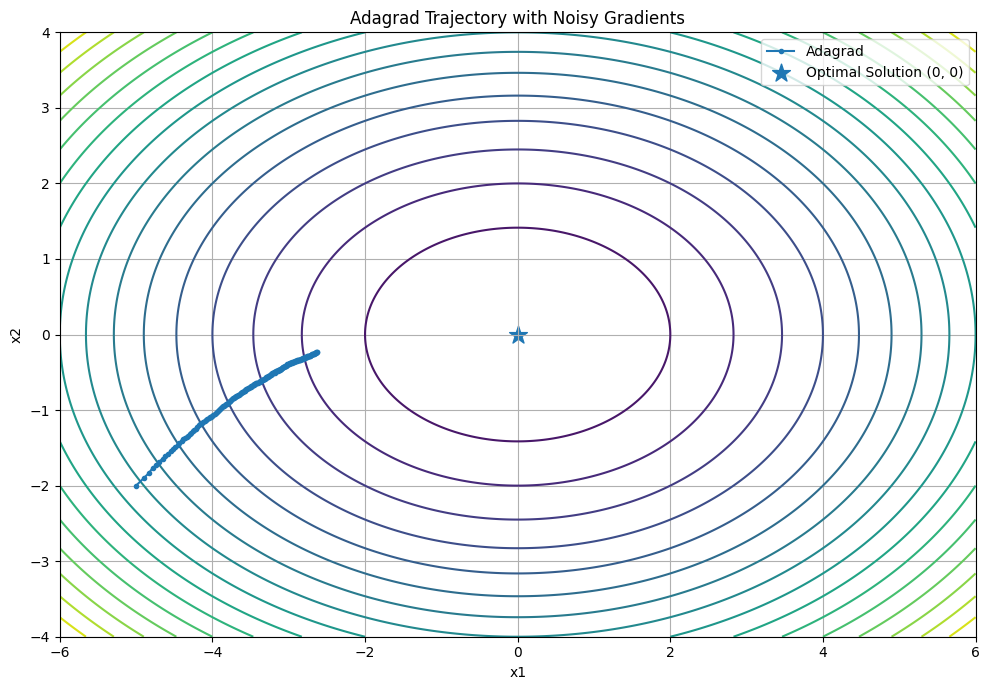

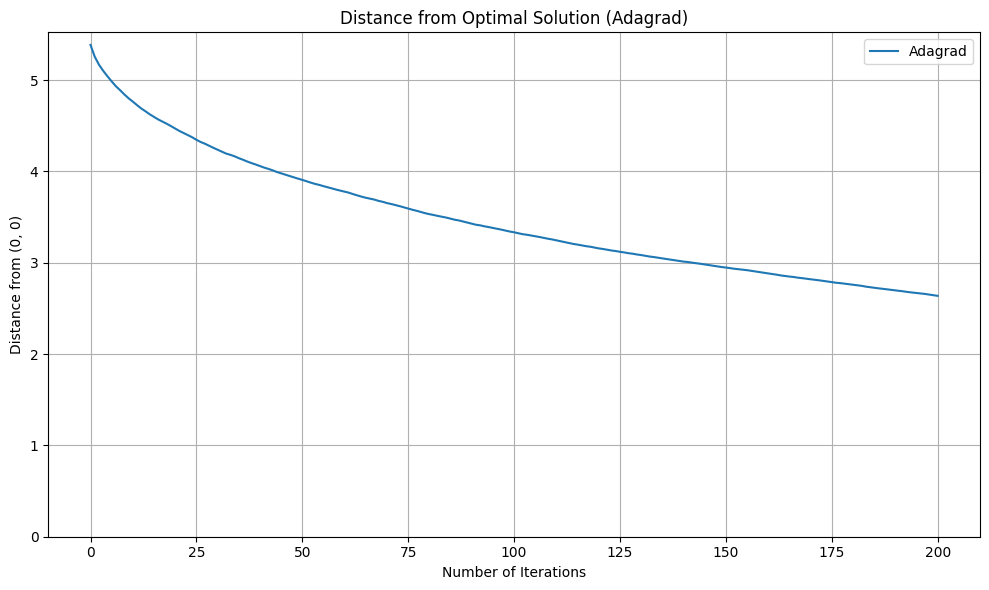

Final distance from optimum (Adagrad): 2.637446


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
from d2l import tensorflow as d2l

# Our group's seed
tf.random.set_seed(10)

def f(x1, x2):  # Objective function (same as Ex 4.1)
    return x1 ** 2 + 2 * x2 ** 2

def f_grad(x1, x2):  # Gradient of the objective function
    return 2 * x1, 4 * x2

def adagrad_updater(x1, x2, s1, s2, f_grad): # Now accepts s1 and s2
    # Calculate the gradient
    g1, g2 = f_grad(x1, x2)

    # Simulate noisy gradient (as in Ex 4.1)
    g1 += tf.random.normal([], 0.0, 1)
    g2 += tf.random.normal([], 0.0, 1)

    # Accumulate squared gradients (s1 and s2 are passed in and updated)
    s1_new = s1 + tf.square(g1)
    s2_new = s2 + tf.square(g2)

    # Adaptive learning rate for each parameter
    # Epsilon (1e-6) added for numerical stability
    eta = 0.1 # Base learning rate
    x1_new = x1 - eta * g1 / tf.sqrt(s1_new + 1e-6)
    x2_new = x2 - eta * g2 / tf.sqrt(s2_new + 1e-6)

    # Return updated x1, x2, and the new s1, s2 state
    return x1_new, x2_new, s1_new, s2_new

# Run Adagrad and plot the trajectory
# d2l.train_2d will now pass initial s1 and s2 to adagrad_updater (usually default to 0)
trace_adagrad = d2l.train_2d(
    adagrad_updater,
    steps=200,
    f_grad=f_grad
    # Removed s1=0.0, s2=0.0 as d2l.train_2d initializes these internally
)

# Calculate distances from optimum (0,0)
distances_adagrad = []
for x1, x2 in trace_adagrad:
    # Explicitly cast x1 and x2 to float32 to avoid InvalidArgumentError with tf.sqrt
    distance = tf.sqrt(tf.cast(x1, tf.float32)**2 + tf.cast(x2, tf.float32)**2)
    distances_adagrad.append(distance.numpy())

# --- Plotting ---
# Contour plot (copied from Ex 4.1 for context)
x1_values = tf.linspace(-6.0, 6.0, 400)
x2_values = tf.linspace(-4.0, 4.0, 400)
X1, X2 = tf.meshgrid(x1_values, x2_values)
Z = f(X1, X2)

plt.figure(figsize=(10, 7))
plt.contour(X1.numpy(), X2.numpy(), Z.numpy(), levels=20)

# Plot Adagrad trajectory
x1_history_adagrad = [float(point[0]) for point in trace_adagrad]
x2_history_adagrad = [float(point[1]) for point in trace_adagrad]
plt.plot(x1_history_adagrad, x2_history_adagrad, marker='o', markersize=3, linestyle='-', label='Adagrad')

# Mark the optimal solution
plt.scatter(0, 0, marker='*', s=180, label='Optimal Solution (0, 0)')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Adagrad Trajectory with Noisy Gradients')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot distance over iterations
plt.figure(figsize=(10, 6))
plt.plot(range(len(distances_adagrad)), distances_adagrad, label='Adagrad')
plt.xlabel('Number of Iterations')
plt.ylabel('Distance from (0, 0)')
plt.title('Distance from Optimal Solution (Adagrad)')
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final distance from optimum (Adagrad): {distances_adagrad[-1]:.6f}")

### Exercise 4.5

Assume that $f(x)=x^2(1+\sin x)$. How many local minima does $f$ have? Can you change $f$ in such a way that, to minimize it, one needs to evaluate all the local minima?

**[5 Marks]**

### Solution for Exercise 4.5

#### Part 1: How many local minima does $f(x)=x^2(1+\sin x)$ have?

Properties of the function $f(x) = x^2(1 + \sin x)$:

1.  **Non-negativity:**
    *   The term $x^2$ is always non-negative ($x^2 \ge 0$).
    *   The term $(1 + \sin x)$ is also always non-negative, because the range of $\sin x$ is $[-1, 1]$, so $0 \le (1 + \sin x) \le 2$.
    *   Since both components are non-negative, their product $f(x)$ is always non-negative ($f(x) \ge 0$).

2.  **Global Minima (where $f(x) = 0$):**
    *   For $f(x)$ to be zero, either $x^2 = 0$ (which implies $x=0$) or $(1 + \sin x) = 0$.
    *   $(1 + \sin x) = 0$ implies $\sin x = -1$.
    *   The values of $x$ for which $\sin x = -1$ are $x = \frac{3\pi}{2} + 2k\pi$, where $k$ is any integer (i.e., $k \in \{\ldots, -2, -1, 0, 1, 2, \ldots\}$). This includes points like $x = \ldots, -\frac{5\pi}{2}, -\frac{\pi}{2}, \frac{3\pi}{2}, \frac{7\pi}{2}, \ldots$.

    *   Therefore, $f(x) = 0$ at $x=0$ and at all points $x = \frac{3\pi}{2} + 2k\pi$.

3.  **Conclusion on Local Minima:**
    Since $f(x)$ is always non-negative, any point where $f(x) = 0$ must be an absolute (global) minimum of the function. Every global minimum is also, by definition, a local minimum.

    As there are infinitely many integer values for $k$, there are **infinitely many** points where $f(x) = 0$. Each of these points is a global minimum, and thus also a local minimum.

    So, $f(x)=x^2(1+\sin x)$ has **infinitely many local minima**.

#### Part 2: Can you change $f$ in such a way that, to minimize it, one needs to evaluate all the local minima?

The original function has infinitely many global minima, all with the exact same value of 0. To "minimize" this function, one simply needs to find *any* one of these points. There's no inherent need to evaluate all of them to determine the minimum value.

To create a scenario where one would *need* to evaluate all (or a significant number of) local minima to find the true global minimum, the modified function would need to have the following characteristics:

1.  **Multiple Distinct Local Minima:** The function must possess many local minima, and critically, the function values at these local minima must be *different*. This means some local minima are "deeper" than others.

2.  **A Unique Global Minimum:** Among all these local minima, there should be one (or a small set) that has the absolute lowest function value. This is the true global minimum we are trying to find.

3.  **Unpredictable Ordering of Minima:** The values of these local minima should not follow an easily predictable pattern (e.g., monotonically decreasing as $x$ increases). If they did, an optimization algorithm could potentially infer the global minimum without exploring all local minima (e.g., by always moving towards deeper wells).

**Modification Idea:**
We could modify $f(x) = x^2(1 + \sin x)$ by adding a complex, non-periodic, and potentially non-convex perturbation term that subtly alters the depth of each minimum. The goal is to make each of the current $x = \frac{3\pi}{2} + 2k\pi$ (where $f(x)=0$) become a local minimum with a slightly different, non-obvious value. One of these would then be the unique global minimum.

For example, consider a function like:

$f_{modified}(x) = x^2(1 + \sin x) + \epsilon(x) \cdot \cos(\gamma x) - \delta_0 e^{-(x-x_{global}^*)^2 / \sigma^2}$

Where:
*   $\epsilon(x) \cdot \cos(\gamma x)$ is a small, spatially varying (non-periodic relative to $\sin x$) term that perturbs the depths of the local minima created by $x^2(1+\sin x)$. This would make the function values at $x = \frac{3\pi}{2} + 2k\pi$ no longer all zero, but rather slightly positive or negative, creating distinct local minima depths.
*   $-\delta_0 e^{-(x-x_{global}^*)^2 / \sigma^2}$ is an additional term that creates a *single, unique, and deepest* global minimum at a specific location $x_{global}^*$ (e.g., one of the $x = \frac{3\pi}{2} + 2k\pi$ points). This term would make that particular minimum slightly deeper than all others.

The challenge with such a modification is to ensure that the pattern of local minima depths is sufficiently complex that a simple gradient descent or other local search algorithm would easily get trapped in a suboptimal local minimum. To *guarantee* finding the true global minimum in such a landscape, one would typically employ **global optimization techniques** like multi-start optimization (running local optimizers from many different initial points) or evolutionary algorithms. These methods inherently involve exploring and effectively "evaluating" multiple local minima to identify the deepest one.

### Code Illustration for Exercise 4.5

This code section provides a visual demonstration of the concepts discussed in Exercise 4.5.

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12647/2089562538.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_values, y_values, label='$f(x) = x^2(1 + \sin x)$', color='blue')
/tmp/ipykernel_12647/2089562538.py:38: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Function $f(x) = x^2(1 + \sin x)$ with Infinite Global Minima')


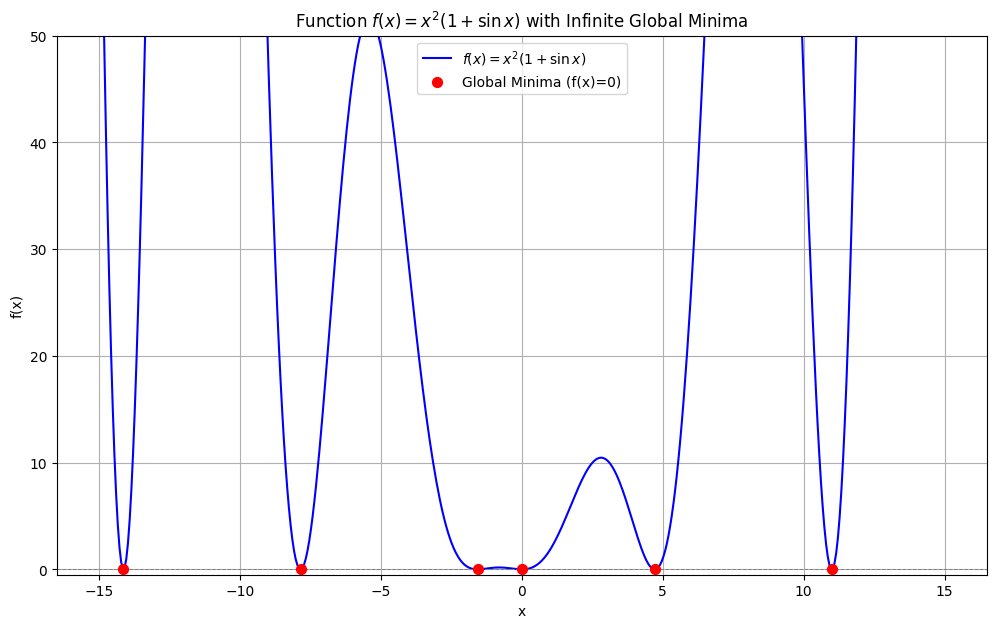

As shown in the plot, f(x) touches 0 at multiple points. Since f(x) >= 0 for all x, all points where f(x)=0 are global minima, and thus local minima. There are infinitely many such points.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Part 1: Plotting f(x) = x^2(1 + sin x) ---

def f(x):
    return x**2 * (1 + np.sin(x))

def df(x):
    # Derivative of f(x) = x^2 + x^2 sin(x)
    # f'(x) = 2x + 2x sin(x) + x^2 cos(x)
    return 2*x + 2*x*np.sin(x) + x**2*np.cos(x)

# Generate x values
x_values = np.linspace(-15, 15, 500)
y_values = f(x_values)
y_prime_values = df(x_values)

plt.figure(figsize=(12, 7))
plt.plot(x_values, y_values, label='$f(x) = x^2(1 + \sin x)$', color='blue')

# Highlight points where f(x) = 0 (global minima)
# These occur at x=0 and x = 3pi/2 + 2k*pi
zero_points = []
for k in range(-3, 4):
    val = (3*np.pi/2) + 2*k*np.pi
    if -15 <= val <= 15:
        zero_points.append(val)
zero_points.append(0.0)
zero_points = np.array(sorted(list(set(zero_points))))

plt.scatter(zero_points, f(zero_points), color='red', marker='o', s=50, zorder=5, label='Global Minima (f(x)=0)')

# Plot the derivative to show where it crosses zero (potential local minima/maxima)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
# plt.plot(x_values, y_prime_values, label="f'(x)", color='green', linestyle=':', alpha=0.7)

plt.title('Function $f(x) = x^2(1 + \sin x)$ with Infinite Global Minima')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-0.5, 50)
plt.grid(True)
plt.legend()
plt.show()

print("As shown in the plot, f(x) touches 0 at multiple points. Since f(x) >= 0 for all x, all points where f(x)=0 are global minima, and thus local minima. There are infinitely many such points.")


#### Part 2: Conceptual Modified Function with Distinct Local Minima

To illustrate a function where one needs to evaluate multiple local minima to find the global minimum, we can construct a function that has several 'wells' of varying depths. Here's a conceptual example using a sum of Gaussian-like terms, each centered at a different point with different 'heights' to simulate varying local minimum depths.

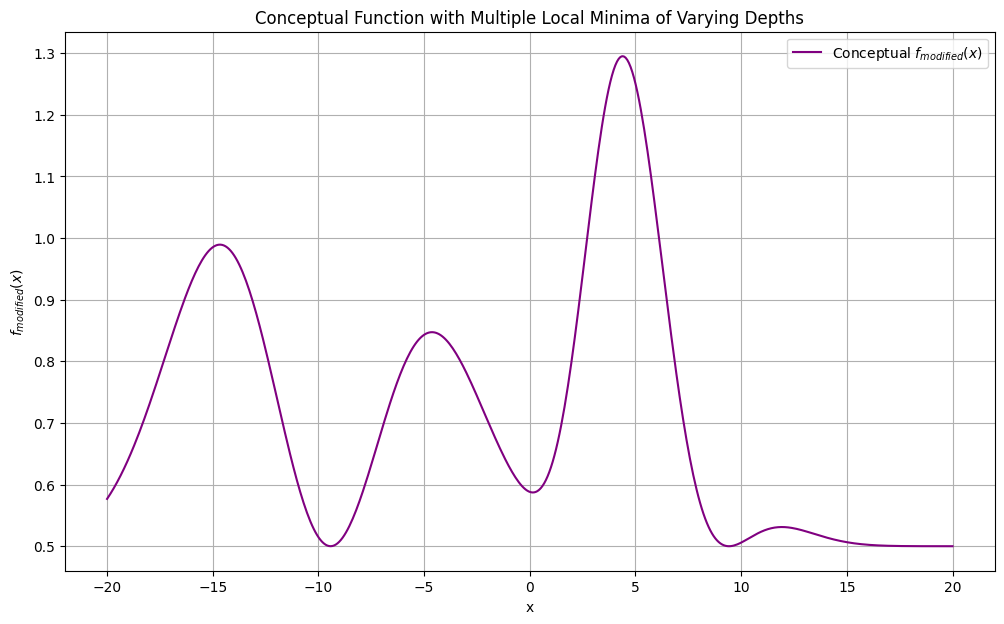

As seen in this conceptual plot, the function has several 'dips' or local minima, each with a different minimum value. To find the *absolute lowest* point (the global minimum), an optimizer would need to explore and compare the values at multiple such local minima. A simple gradient descent starting from an arbitrary point could get stuck in a 'shallow' local minimum, missing the true global minimum.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Part 2: Conceptual Modified Function ---

def conceptual_f_modified(x):
    # This function is designed to have multiple local minima with different depths.
    # It's a sum of inverse Gaussians or similar shapes to create 'valleys'.
    # The goal is to show distinct local minima values.

    # Example 1: Combining periodic with decaying term
    # This term creates local minima around x = 2k*pi but with varying depths
    term1 = 0.5 * (np.sin(x/2) + 1.0) * np.exp(-0.05 * (x-5)**2)

    # Example 2: Another set of local minima
    term2 = 0.8 * (np.cos(x/3) + 1.0) * np.exp(-0.03 * (x+10)**2)

    # Example 3: A deeper, global minimum
    term3 = -0.3 * np.exp(-0.2 * (x-2)**2) # A strong, localized dip

    # Base background (slightly positive so minima are negative)
    base = 0.5

    return base + term1 + term2 + term3


x_values_mod = np.linspace(-20, 20, 500)
y_values_mod = conceptual_f_modified(x_values_mod)

plt.figure(figsize=(12, 7))
plt.plot(x_values_mod, y_values_mod, label='Conceptual $f_{modified}(x)$', color='purple')

plt.title('Conceptual Function with Multiple Local Minima of Varying Depths')
plt.xlabel('x')
plt.ylabel('$f_{modified}(x)$')
plt.grid(True)
plt.legend()
plt.show()

print("As seen in this conceptual plot, the function has several 'dips' or local minima, each with a different minimum value. To find the *absolute lowest* point (the global minimum), an optimizer would need to explore and compare the values at multiple such local minima. A simple gradient descent starting from an arbitrary point could get stuck in a 'shallow' local minimum, missing the true global minimum.")
